# Exploratory and Explanatory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
from ucimlrepo import fetch_ucirepo 
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 

&nbsp;

## Calculate the number and percentage of missing values ​​in each column

In [3]:
missing_values = X.isnull().sum()
missing_percentage = (missing_values / len(X)) * 100

missing_data = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
}).sort_values(by='Missing Values', ascending=False)

missing_data[missing_data['Missing Values'] > 0] 

,Missing Values,Percentage
ca,4,1.320132
thal,2,0.660066


&nbsp;

## Using a Histogram to See the Distribution of Data.

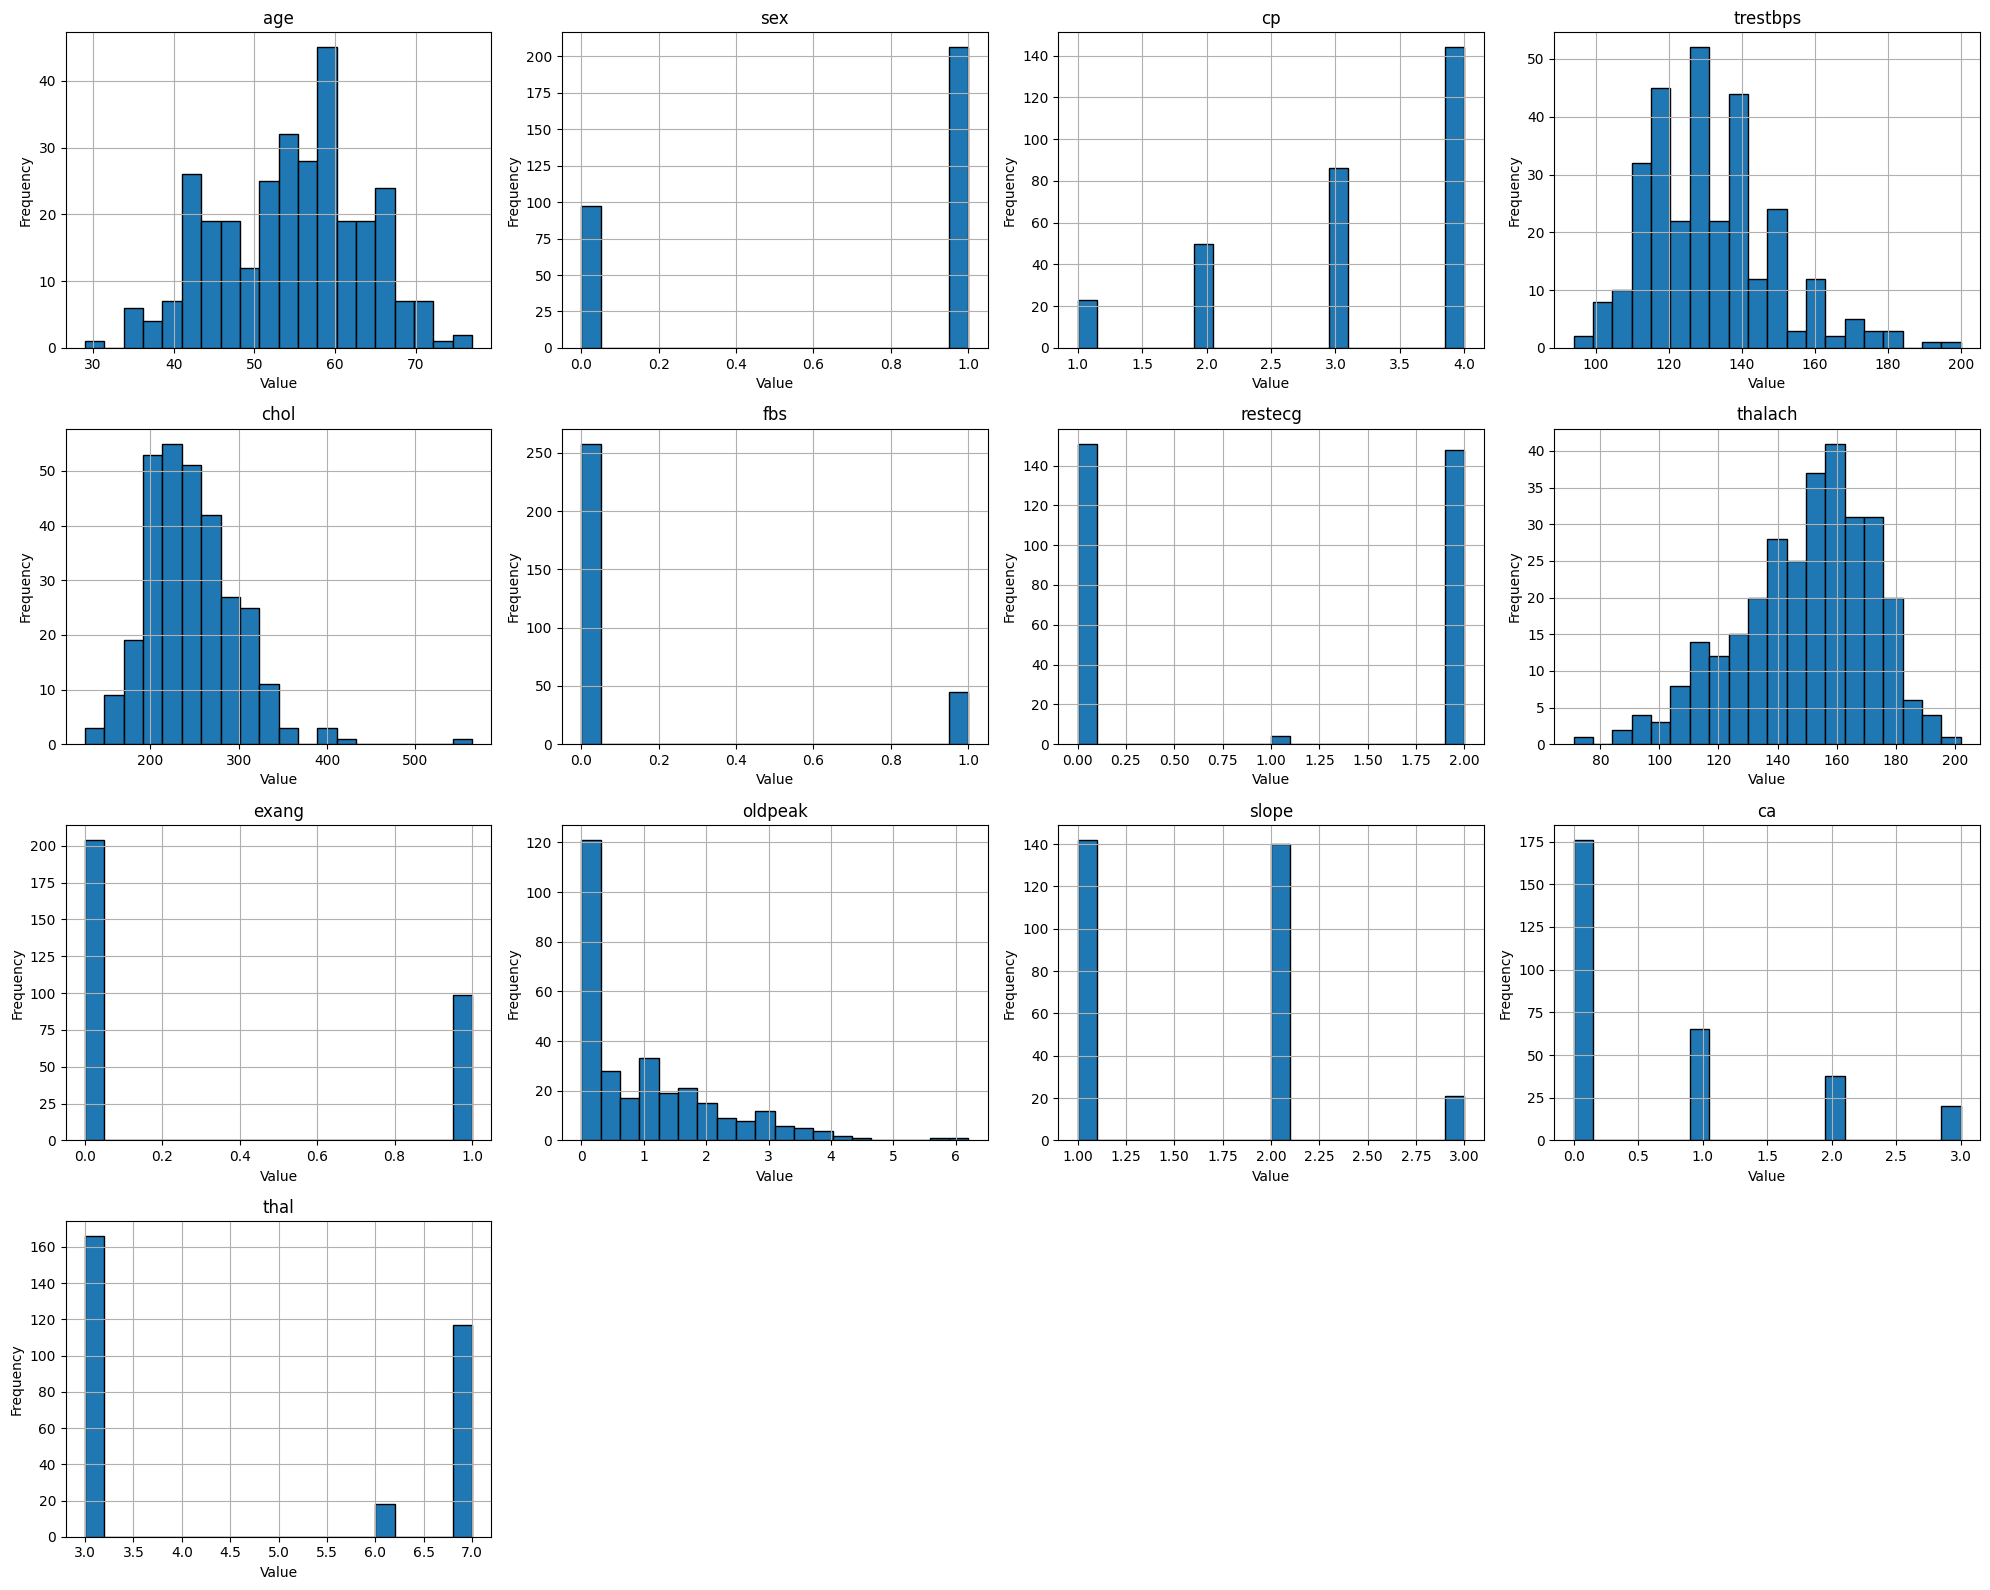

In [4]:
# Settings up number of row and column based on how many feature variable
num_vars = X.shape[1]
n_cols = 4  
n_rows = -(-num_vars // n_cols)  

# Creating subplot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))

# flattening the axis into 1d array
axes = axes.flatten()

# plotting each variable
for i, column in enumerate(X.columns):
    X[column].hist(ax=axes[i], bins=20, edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# deleting subplot with empty feature
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

&nbsp;

## Visualizing Data Distribution for Multiple Columns

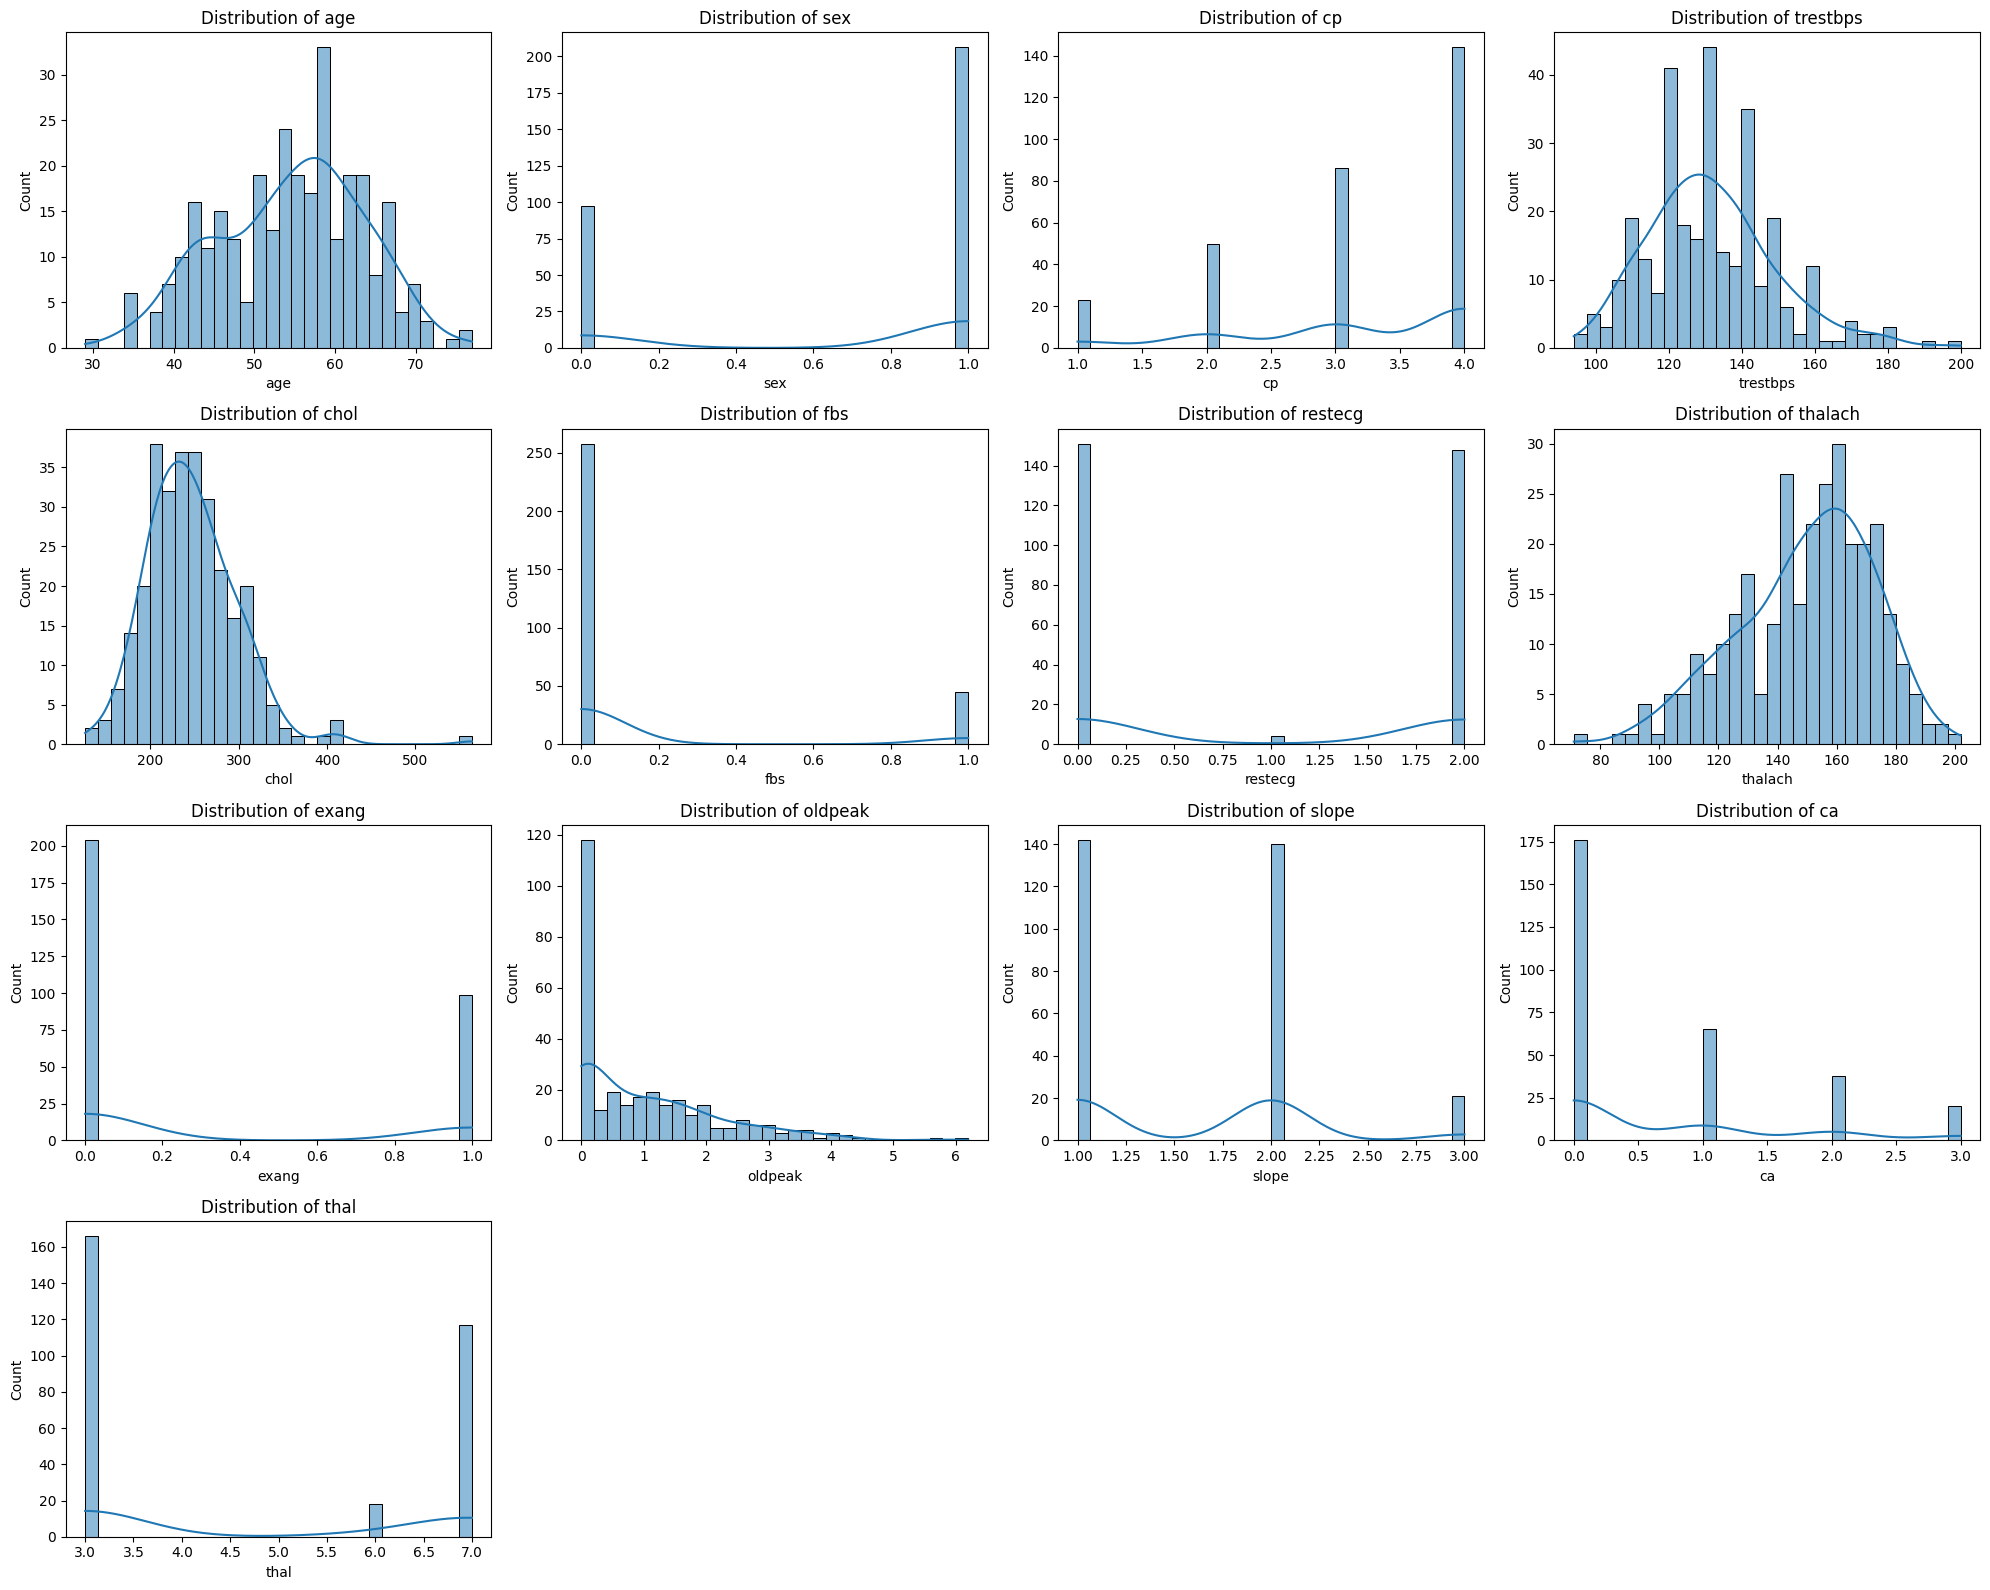

In [5]:
n_cols = len(X.columns)
n_display_cols = 4  # How many plots per row
n_rows = math.ceil(n_cols / n_display_cols)

plt.figure(figsize=(20, 4 * n_rows))

for i, column in enumerate(X.columns, 1):
    plt.subplot(n_rows, n_display_cols, i)
    sns.histplot(X[column], kde=True, bins=30)
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

&nbsp;

## Visualizing Correlation Between Numerical Value

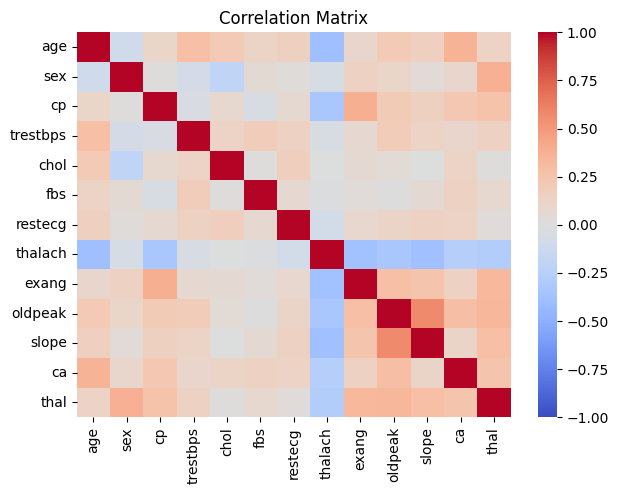

In [6]:
# idk if doing this is relevant for this dataset
plt.figure(figsize=(7, 5))
correlation_matrix = X.corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

&nbsp;

## Calculating Correlation Between Features and Target

In [7]:
target_corr = X.corrwith(y['num'])

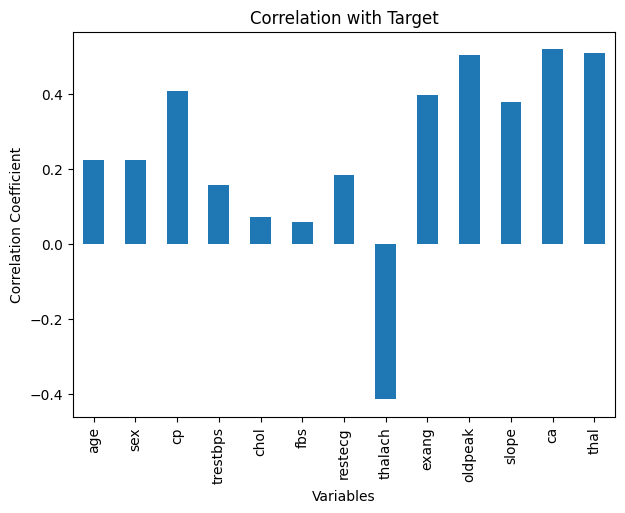

In [8]:
plt.figure(figsize=(7, 5))
target_corr.plot(kind='bar')
plt.title('Correlation with Target')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.show()

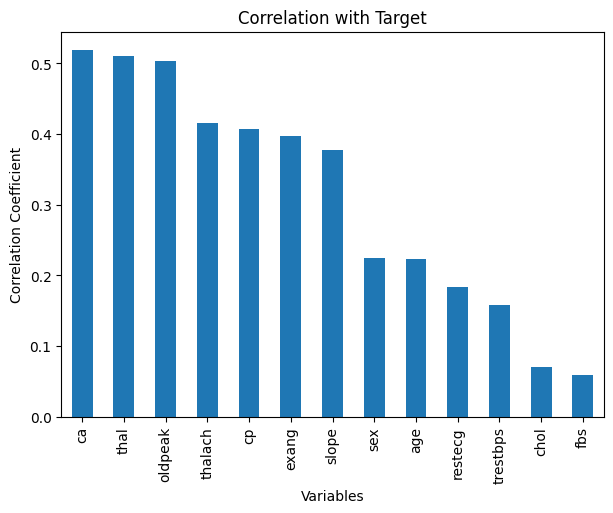

In [9]:
# Optional, we can abs and sort it to get better visualization
target_corr_sorted = target_corr.abs().sort_values(ascending=False)
plt.figure(figsize=(7, 5))
target_corr_sorted.plot(kind='bar')
plt.title('Correlation with Target')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.show()